# Working with HYCOM data

This notebook walks through common xarray operations on HYCOM output: slicing, regional masking, curvilinear plotting, time-based aggregations, and `groupby` for seasonal analysis.

We open the archive lazily with `chunks={"time": 1}` so the examples work on any size of archive without loading everything into memory (see **[Lazy loading & chunking](lazy-loading.ipynb)** to learn more about chunk sizes and lazy loading).

In [1]:
import xhycom

GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

# Open the full archive lazily — no data read until .compute()
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1})

In [2]:
ds

<xarray.Dataset> Size: 1TB
Dimensions:     (y: 380, x: 400, time: 366, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

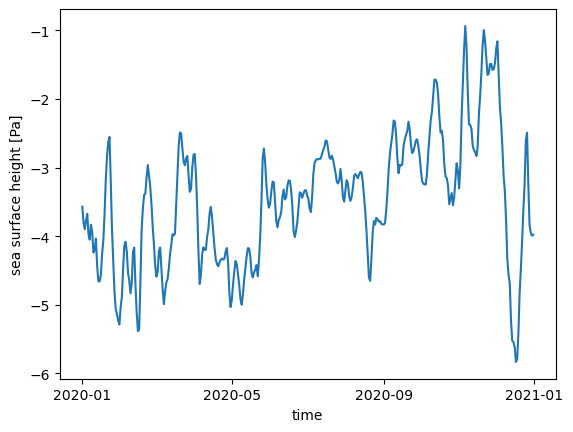

In [3]:
ds["srfhgt"].mean(dim=["y", "x"]).plot()

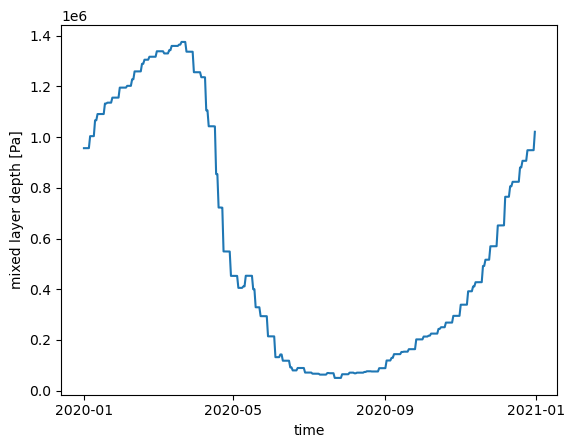

In [5]:
ds["mix_dpth"].mean(dim=["y", "x"]).plot()

## Physical units and derived fields

By default the data come back exactly as stored on disk, so some fields are in
HYCOM's native units — sea-surface height as geopotential, and layer thickness /
mixed-layer depth as pressure in Pa.  Pass `postprocess=True` to convert these to
physical units and add a few derived fields:

| Field | Native | `postprocess=True` |
|-------|--------|--------------------|
| `srfhgt` | geopotential (m² s⁻²) | sea-surface height in **m** (÷ g = 9.806) |
| `thknss`, `mix_dpth`, `bl_dpth`, `thmix` | pressure (Pa) | **m** (÷ onem = 9806) |
| `u-vel.`, `v-vel.` | baroclinic (`archv`) / total (`archm`) | **total current** (+ barotropic), tagged `hycom_velocity` |
| `area` | — | `scpx · scpy` (m²), on grid files |
| `landmask` | — | 1 ocean / 0 land, from the bathymetry |

You can also apply it to an already-open dataset with `xhycom.postprocess(ds)`.

**A note on velocities.** HYCOM writes `u-vel.`/`v-vel.` differently per file type: an
instantaneous `archv` stores the **baroclinic** layer velocity, so the total current is
`u-vel. + u_btrop`; a mean `archm` already stores the **total** (the barotropic part is
summed in online). `postprocess=True` reconciles both to the **total current** — adding
the barotropic part for `archv`, annotating `archm` — and records the provenance in
`ds.attrs["archive_type"]` (`"instantaneous"` / `"mean"`) and `da.attrs["hycom_velocity"]`
(`"total"` / `"baroclinic"`). If you select velocities via `variables=`, the barotropic
`u_btrop`/`v_btrop` are pulled in automatically to build the total, then dropped.

In [4]:
# Same archive with native units converted + derived fields added.
# Kept on a separate handle so the rest of the notebook keeps the raw `ds`.
ds_pp = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

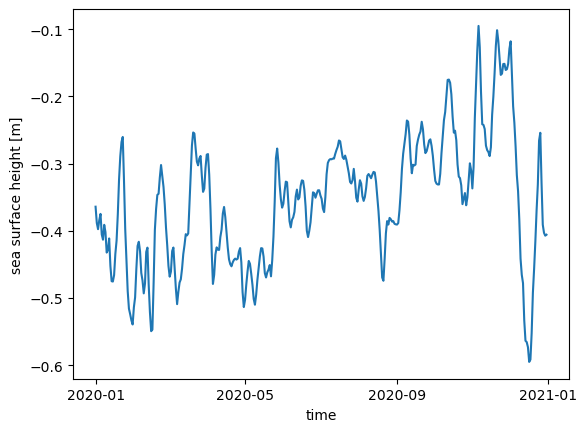

In [6]:
ds_pp["srfhgt"].mean(dim=["y", "x"]).plot()

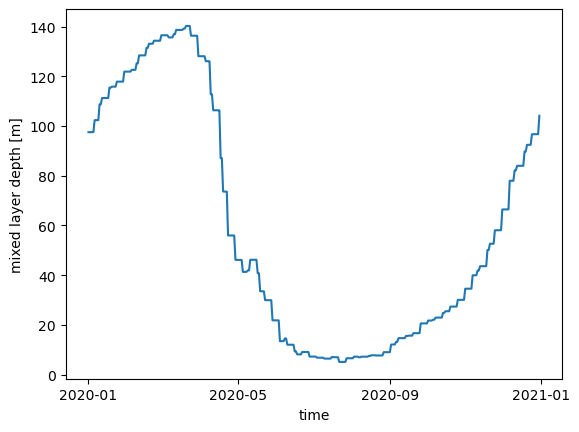

In [7]:
ds_pp["mix_dpth"].mean(dim=["y", "x"]).plot()

In [ ]:
# postprocess reconciles u-vel./v-vel. to the total current, and records how:
ds_pp.attrs["archive_type"], ds_pp["u-vel."].attrs["hycom_velocity"]

## Slicing

xarray's `isel` (index-based) and `sel` (label-based) selectors work directly.

In [8]:
# Surface temperature at the first time step
sst = ds["temp"].isel(time=0, k=0)

In [9]:
sst

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
dask.array<getitem, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 1
    time     object 8B 2020-01-01 00:00:00
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

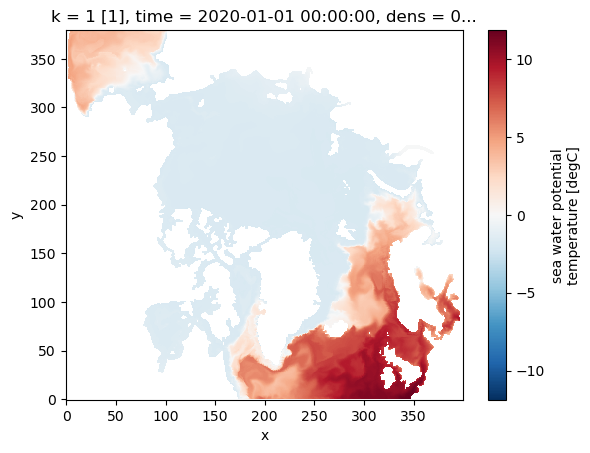

In [10]:
sst.plot()

In [11]:
temp_at_fixed_dens = ds["temp"].isel(time=0).isel(k=13)

In [12]:
temp_at_fixed_dens

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
dask.array<getitem, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 14
    time     object 8B 2020-01-01 00:00:00
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

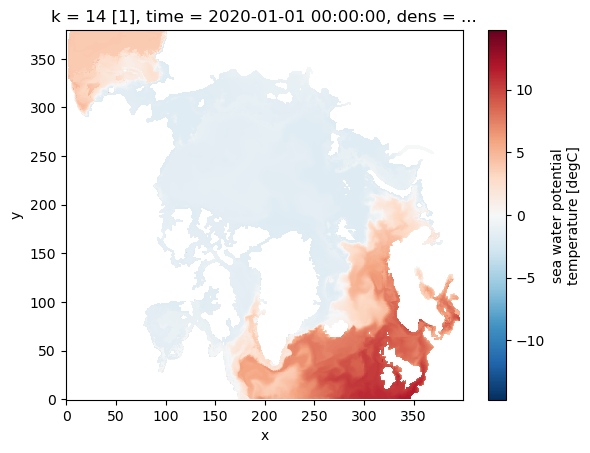

In [13]:
temp_at_fixed_dens.plot()

In [14]:
# Select by layer density instead of layer index
the_same_temp = ds["temp"].isel(time=0).sel(dens=27.0, method="nearest")

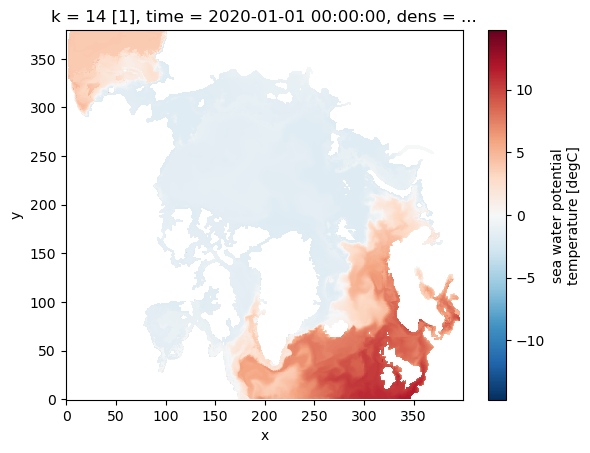

In [15]:
the_same_temp.plot()

## Regional analysis

HYCOM uses a curvilinear grid, so `lon` and `lat` are 2-D arrays — you cannot use `.sel(lon=..., lat=...)` for spatial subsetting.  Instead, build a boolean mask from the coordinate arrays and apply it with `.where()`.

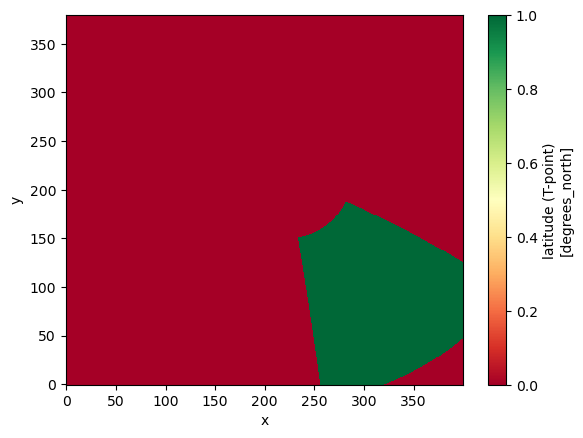

In [16]:
# Boolean mask: True inside the region, False outside
mask = (ds.lon > -30) & (ds.lon < 30) & (ds.lat > 50) & (ds.lat < 80)
mask.plot(cmap='RdYlGn');

Apply the mask to a variable — grid points outside the region become NaN:

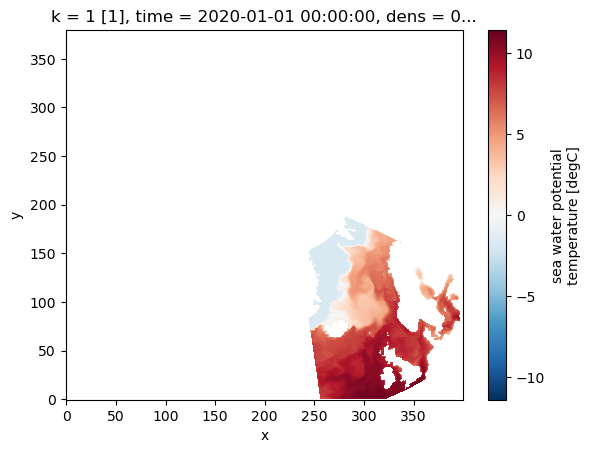

In [18]:
sst_region = ds['temp'].isel(k=0).where(mask)
sst_region.isel(time=0).plot();

With the mask applied, reductions like `.mean()` automatically ignore the masked-out (NaN) points.  Here we compute a time series of mean surface temperature inside the region:

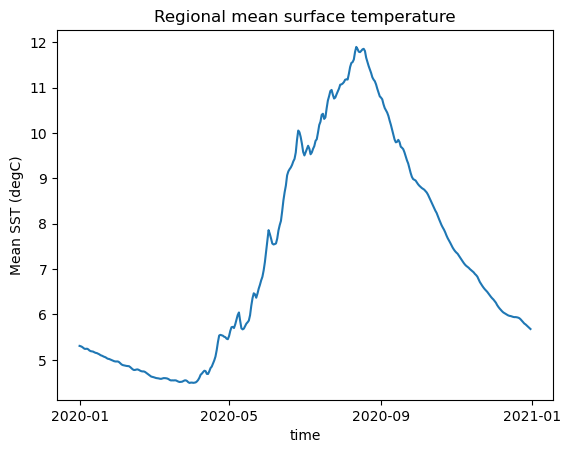

In [19]:
sst_ts = sst_region.mean(dim=['y', 'x']).compute()
sst_ts.plot()
import matplotlib.pyplot as plt
plt.ylabel('Mean SST (degC)')
plt.title('Regional mean surface temperature');

The same pattern works for any variable.  For example, sea-ice extent (fraction of the masked area with ice concentration above 15 %):

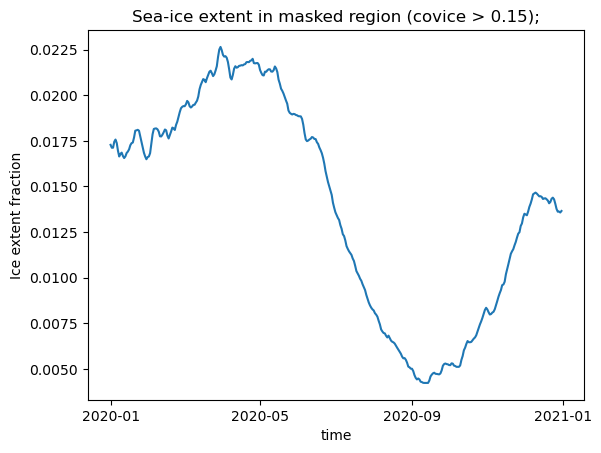

In [20]:
ice_extent = (ds['covice'].where(mask) > 0.15).mean(dim=['y', 'x']).compute()
ice_extent.plot()
plt.ylabel('Ice extent fraction')
plt.title('Sea-ice extent in masked region (covice > 0.15);');

## Seasonal and monthly analysis with `groupby`

`groupby` splits the time axis by a label — calendar month, season, year — and applies a reduction.  Everything stays lazy until `.compute()` is called.

In [21]:
# 4-season mean of surface temperature (reads all files on .compute())
sst_seasonal = ds["temp"].isel(k=0).groupby("time.season").mean()
sst_seasonal

<xarray.DataArray 'temp' (season: 4, y: 380, x: 400)> Size: 5MB
dask.array<stack, shape=(4, 380, 400), dtype=float64, chunksize=(1, 380, 400), chunktype=numpy.ndarray>
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

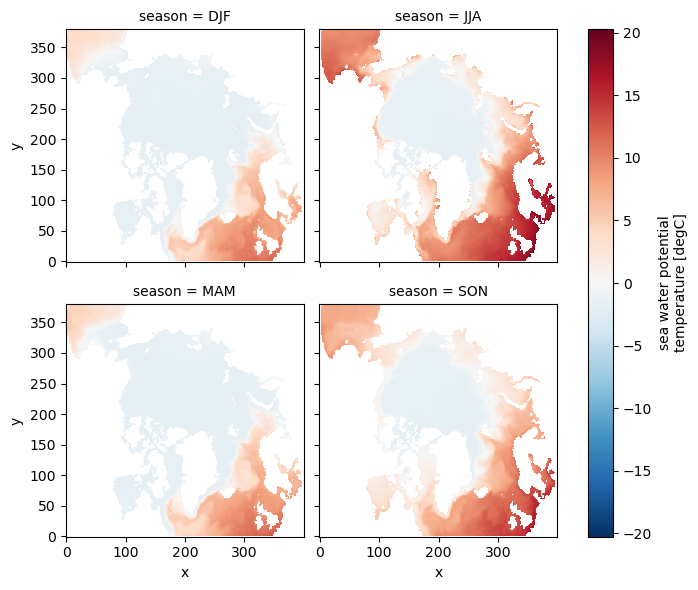

In [23]:
sst_seasonal.plot(col="season", col_wrap=2)

### March sea-ice concentration

Monthly groupby lets you compute a climatological mean for any specific month. Here we extract March (month 3) mean sea-ice concentration across all years.

In [24]:
# Climatological March sea-ice concentration
ice_monthly = ds["covice"].groupby("time.month").mean()
march_ice = ice_monthly.sel(month=3)
march_ice

<xarray.DataArray 'covice' (y: 380, x: 400)> Size: 1MB
dask.array<getitem, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    month    int64 8B 3
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea ice coverage fraction
    units:      1

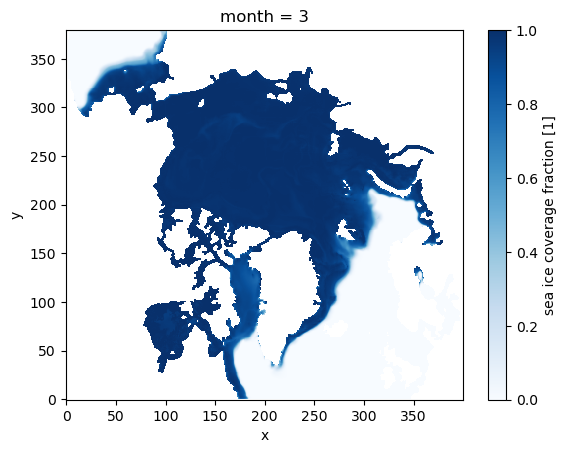

In [25]:
march_ice.plot(cmap="Blues", vmin=0, vmax=1)

## Anomalies

Subtract the climatological monthly mean to isolate interannual or seasonal variability.

In [31]:
import matplotlib.pyplot as plt

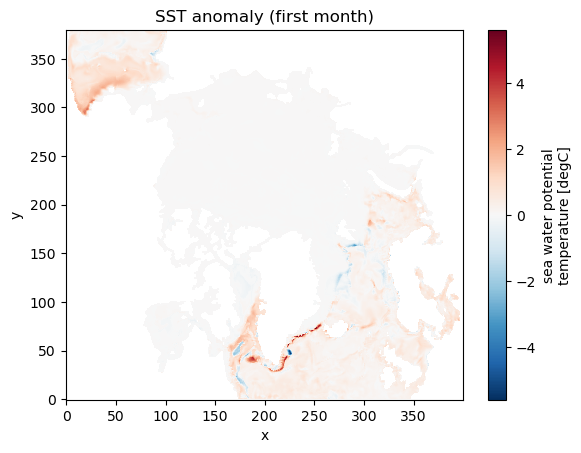

In [32]:
# Climatological monthly mean
clim = ds['temp'].isel(k=0).groupby('time.month').mean()

# Anomaly: each time step minus its climatological month
anom = ds['temp'].isel(k=0).groupby('time.month') - clim

# Plot the anomaly for one time step
anom.isel(time=0).compute().plot(cmap='RdBu_r', center=0)
plt.title('SST anomaly (first month)');

## Mixed layer depth

`mix_dpth` is stored in Pa — divide by ~9806 to convert to metres.  (With
`postprocess=True` this conversion is done for you, so `ds_pp["mix_dpth"]` is
already in metres and the manual `/ 9806.0` below is unnecessary.)

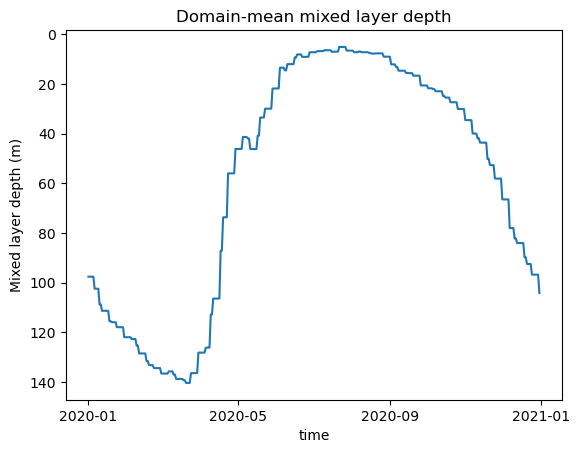

In [33]:
# Mixed layer depth in metres, time series averaged over the domain
mld_m = (ds['mix_dpth'] / 9806.0).mean(dim=['y', 'x']).compute()
mld_m.attrs['units'] = 'm'
mld_m.plot()
plt.ylabel('Mixed layer depth (m)')
plt.gca().invert_yaxis()          # depth increases downward
plt.title('Domain-mean mixed layer depth');

## Saving a subset to NetCDF

Use `to_netcdf()` to write a subset of variables or time steps to a file for sharing or use with tools that do not read `.ab` format directly.

In [34]:
# Write the top 10 layers of T and S for the first 12 time slices
subset = ds[['temp', 'salin']].isel(time=slice(0, 12))
subset.compute().to_netcdf('hycom_TS_2020.nc')
print('Saved hycom_TS_2020.nc')

Saved hycom_TS_2020.nc


## Plotting

In [35]:
sss = ds["salin"].isel(time=0, k=0)

For quick plots, use xarray's in-built plotting.


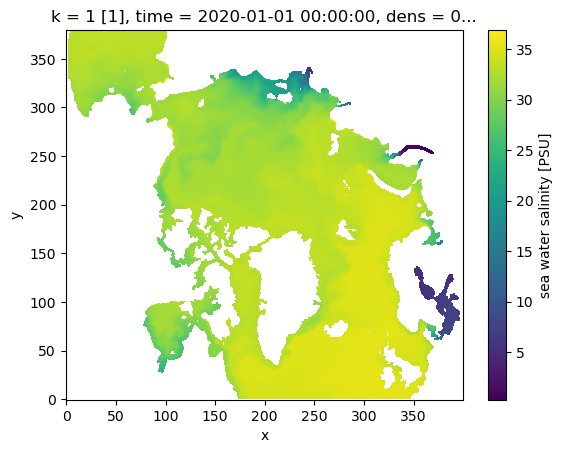

In [36]:
sss.plot()

Because `lon` and `lat` are 2-D curvilinear arrays, use `pcolormesh` directly rather than xarray's `.plot()`.  U-point and V-point variables carry `lon_u`/`lat_u` and `lon_v`/`lat_v` coordinates.

In [37]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [38]:
def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax

In [39]:
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)

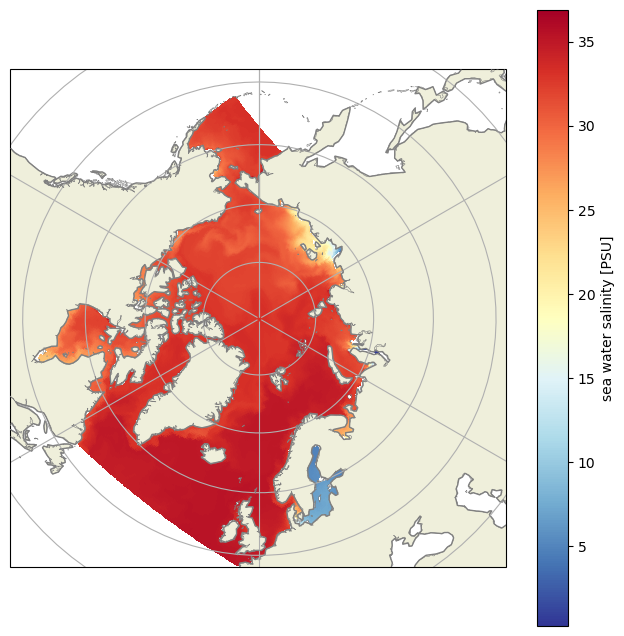

In [40]:
fig, ax = ArcticMap()
p = pcolormesh_curvilinear(sss.lon.values, sss.lat.values, sss.values, ax=ax, cmap="RdYlBu_r")
fig.colorbar(p, ax=ax, label=f"{sss.attrs['long_name']} [{sss.attrs['units']}]")

In [41]:
u = ds["u-vel."].isel(time=0, k=0)

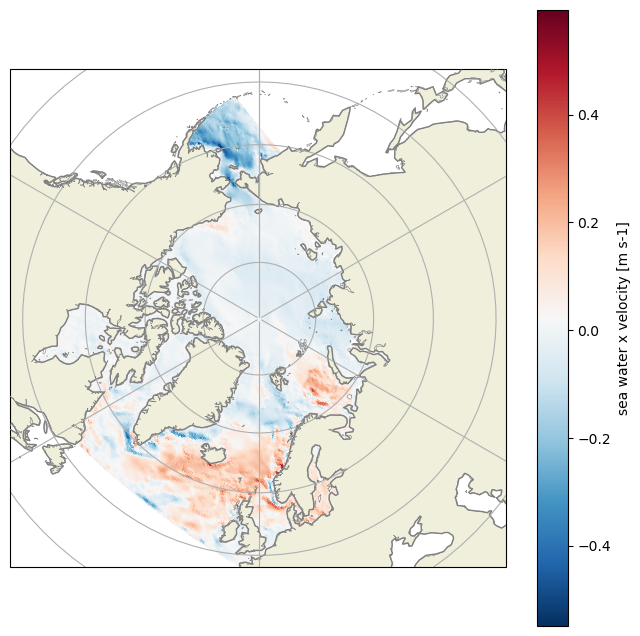

In [42]:
# U-point variable — use lon_u / lat_u

fig, ax = ArcticMap()
p = pcolormesh_curvilinear(u.lon_u.values, u.lat_u.values, u.values, ax=ax, cmap="RdBu_r")
fig.colorbar(p, ax=ax, label=f"{u.attrs['long_name']} [{u.attrs['units']}]")